# SVM
- diabetes.csv
- Hyperparameter tuning


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from mlxtend.plotting import plot_decision_regions
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
# Features and target
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

scaler = StandardScaler()

# split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state=42)

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [18]:
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced']
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'class_weight': [None, 'balanced']
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'degree': [2, 3, 4],
        'class_weight': [None, 'balanced']
    },
    {
        'kernel': ['sigmoid'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'class_weight': [None, 'balanced']
    }
]

grid = GridSearchCV(estimator = SVC(probability=True),
                    param_grid = param_grid,
                    cv = 5,
                    scoring = 'accuracy',
                    n_jobs = -1)

grid.fit(x_train, y_train)

print('✅ Best score: ',grid.best_score_)
print('🚀 Best model: ',grid.best_estimator_)
print('🔰 Best hyperparameters : ',grid.best_params_)

✅ Best score:  0.7687458349993335
🚀 Best model:  SVC(C=1, probability=True)
🔰 Best hyperparameters :  {'C': 1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}


In [21]:
# best model.
best_model = grid.best_estimator_

accuracy :  0.7337662337662337



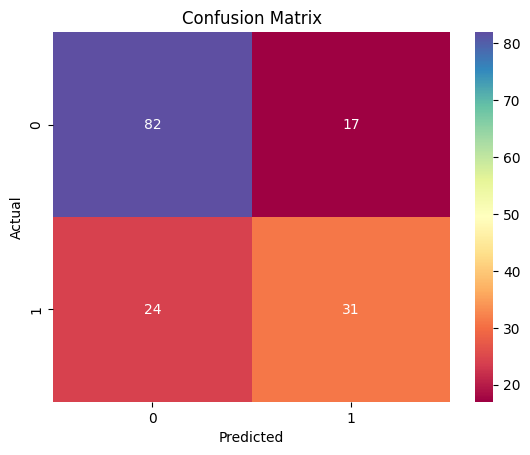

In [20]:
# evaluation
y_Pred = best_model.predict(x_test)
print('accuracy : ',accuracy_score(y_test, y_Pred))

print()

sns.heatmap(confusion_matrix(y_test, y_Pred), annot = True, cmap = 'Spectral')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

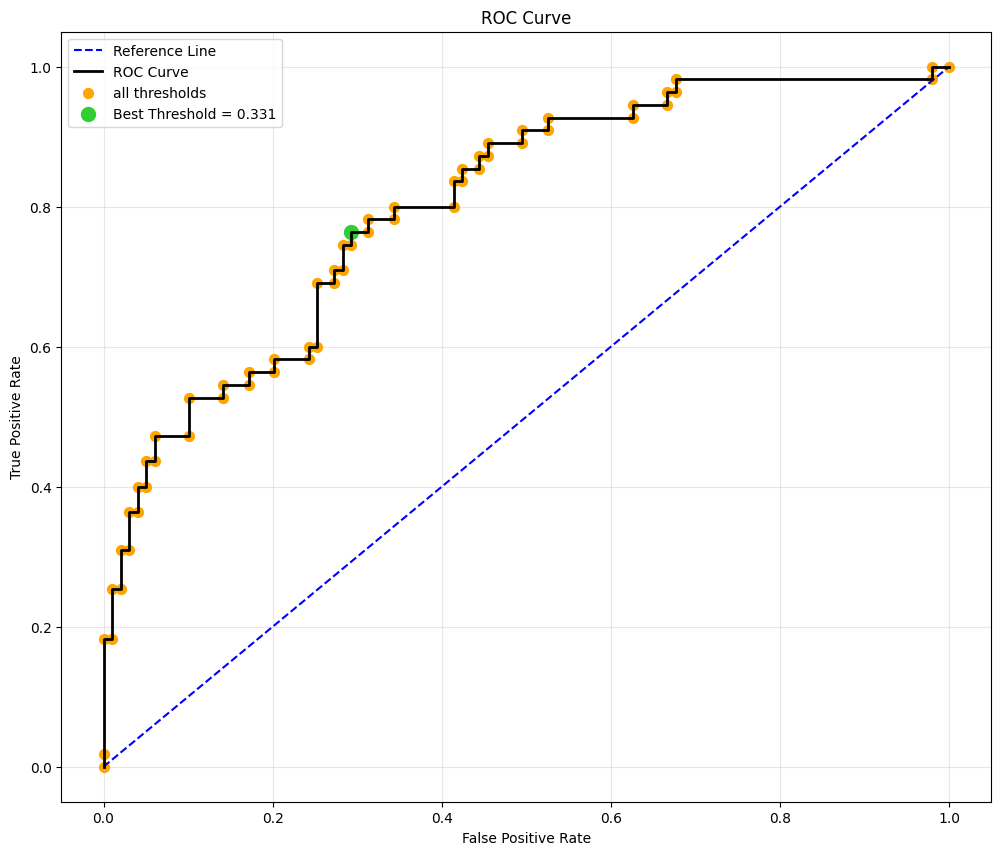


 AUC Score: 0.8049586776859504


In [27]:
# ROC curve
y_Score = best_model.predict_proba(x_test)[:, 1]

# optimal threshold
fpr, tpr, thresholds = roc_curve(y_test, y_Score)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]


plt.figure(figsize=(12,10))

plt.plot([0,1], [0,1], '--', color='blue', label='Reference Line')
plt.plot(fpr, tpr, color='black', linewidth=2, label='ROC Curve')
plt.scatter(fpr, tpr, color = 'orange', s = 50, label = 'all thresholds')
plt.scatter(
    fpr[optimal_idx],
    tpr[optimal_idx],
    color='limegreen',
    s=100,
    label=f'Best Threshold = {optimal_threshold:.3f}'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("\n AUC Score:", roc_auc_score(y_test, y_Score))

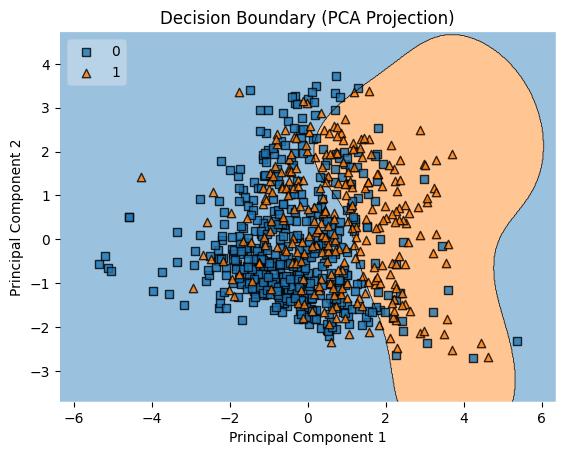

In [28]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(scaler.transform(x))

best_model.fit(x_pca, y)

plot_decision_regions(x_pca,y.to_numpy(),clf=best_model,legend=2)
plt.title("Decision Boundary (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()